# 11 - Forward Model Diagnostics and Learning Curves

## Objective

This notebook checks the robustness of the clean ExtraTrees forward baseline.

It does **not** overwrite the final submission file.  
Its role is to answer these questions:

- Is the model overfitting?
- Are the validation errors stable across targets?
- Are distance targets harder than fragmentation targets?
- Do errors change across gravity regimes?
- Do learning curves suggest that more data could help?

The notebook uses the same base modeling logic as the clean forward pipeline:

```text
Raw inputs
→ physics-inspired features
→ target-specific feature sets
→ make_pipeline
→ ColumnTransformer
→ ExtraTreesRegressor
→ diagnostics
```

## 1. Imports and project paths

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data:", FORWARD_DIR)
print("Reports:", REPORTS_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Reports: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports


## 2. Load data

In [2]:
input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor",
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize",
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

raw_train = pd.read_csv(FORWARD_DIR / "train.csv")[input_cols]
y = pd.read_csv(FORWARD_DIR / "train_labels.csv")[target_cols]

print("Raw train:", raw_train.shape)
print("Targets:", y.shape)
display(raw_train.head())
display(y.head())

Raw train: (2930, 8)
Targets: (2930, 6)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,3.826405,0.818303,0.861258,1.305809,0.337215,3.71,0.781263,0.784028
1,2.828754,1.193036,0.561245,3.494501,0.058029,1.62,0.136205,0.922737
2,3.068907,0.605872,0.948860,1.366386,0.315632,3.71,0.774704,0.954922
3,2.700574,1.073708,0.713705,3.599419,0.033062,1.62,0.144204,0.932911
4,3.484022,0.863568,1.237205,1.996742,0.278207,9.81,0.414620,1.260855


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,76.972350,0.184728,0.016671,198.938699,175.527939,76.235779
1,269.057465,0.000622,0.916734,239.268477,447.157838,141.894047
2,104.070923,0.070343,0.094438,192.986417,189.286407,84.235774
3,257.618403,0.001026,0.880122,289.289693,500.000028,169.866473
4,111.717167,0.058576,0.136166,94.229304,97.614864,42.928393


## 3. Feature engineering

The same physics-inspired feature engineering is reused from the clean forward pipeline.

In [3]:
def add_physics_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    eps = 1e-9

    # Energy transfer
    X["effective_energy"] = X["energy"] * X["coupling"]
    X["log_energy"] = np.log1p(X["energy"])
    X["log_effective_energy"] = np.log1p(X["effective_energy"])

    # Angle decomposition
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
    X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]

    # Material and fragmentation proxies
    X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
    X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
    X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
    X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
    X["coupling_porosity"] = X["coupling"] * X["porosity"]
    X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
    X["porosity_strength"] = X["porosity"] * X["strength"]

    # Gravity-scaled distance proxies
    X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
    X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
    X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
    X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

    # Atmosphere and drag proxies
    X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
    X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
    X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
    X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

    # Pi-like scaling proxies
    X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
    X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
    X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

    # Regime indicators
    X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
    X["strength_regime"] = (X["strength"] > 2.6).astype(int)
    X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
    X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)

    X["regime_combo"] = (
        X["porosity_regime"] * 8
        + X["strength_regime"] * 4
        + X["angle_regime"] * 2
        + X["atm_regime"]
    )

    # Additional interactions
    X["scaled_energy"] = X["effective_energy"] / (X["strength"] * np.sqrt(X["gravity"]) + eps)
    X["fragility"] = X["porosity"] / (X["strength"] + eps)
    X["range_proxy"] = (X["effective_energy"] * X["cos_angle"] ** 2) / (X["gravity"] * X["strength"] + eps)
    X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
    X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]

    # Controlled atmosphere ratio
    X["coupling_per_atm_clipped"] = X["coupling"] / (X["atmosphere"] + 1e-3)
    X["log_coupling_per_atm"] = np.log1p(X["coupling_per_atm_clipped"])
    X["retention_factor"] = X["atmosphere"] * X["drag_proxy"] / (X["energy"] + eps)

    return X


X_fe_train = add_physics_features(raw_train)

print("Engineered train:", X_fe_train.shape)

assert X_fe_train.isna().sum().sum() == 0
assert np.isfinite(X_fe_train.select_dtypes(include=[np.number]).values).all()

print("Feature matrix checks passed.")

Engineered train: (2930, 46)
Feature matrix checks passed.


## 4. Feature sets and model builder

In [4]:
raw_features = input_cols.copy()

core_physics_features = raw_features + [
    "effective_energy", "log_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
]

extended_plus_regimes_features = core_physics_features + [
    "pi_gravity_proxy", "pi_strength_proxy", "pi_atmosphere_proxy",
    "scaled_energy", "fragility", "range_proxy",
    "energy_sin_angle", "momentum_proxy",
    "coupling_per_atm_clipped", "log_coupling_per_atm", "retention_factor",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

fragmentation_features = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "drag_proxy", "atmosphere_shape_energy",
    "pi_strength_proxy", "pi_atmosphere_proxy", "scaled_energy", "fragility",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]


def clean_feature_list(features, X):
    seen = set()
    out = []
    for f in features:
        if f in X.columns and f not in seen:
            out.append(f)
            seen.add(f)
    return out


raw_features = clean_feature_list(raw_features, X_fe_train)
core_physics_features = clean_feature_list(core_physics_features, X_fe_train)
extended_plus_regimes_features = clean_feature_list(extended_plus_regimes_features, X_fe_train)
fragmentation_features = clean_feature_list(fragmentation_features, X_fe_train)


def get_features_for_target(target: str):
    if target in fragmentation_targets:
        return fragmentation_features
    return extended_plus_regimes_features


def build_extratrees_pipeline(features, random_state=42):
    selector = ColumnTransformer(
        transformers=[("selected_features", "passthrough", features)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    model = ExtraTreesRegressor(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
    )

    return make_pipeline(selector, model)


def clip_predictions(preds, target):
    preds = np.asarray(preds).copy()
    if target in ["fines_frac", "oversize_frac"]:
        return np.clip(preds, 0, 1)
    return np.clip(preds, 0, None)


def regression_metrics(y_true, y_pred, target_name=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    out = {"MAE": mae, "RMSE": rmse, "R2": r2}

    if target_name is not None:
        out["normalized_MAE"] = mae / (y[target_name].std() + 1e-9)

    return out


feature_summary = pd.DataFrame([
    {"feature_group": "fragmentation_features", "n_features": len(fragmentation_features)},
    {"feature_group": "extended_plus_regimes", "n_features": len(extended_plus_regimes_features)},
])

display(feature_summary)

,feature_group,n_features
0,fragmentation_features,34
1,extended_plus_regimes,46


## 5. Train-vs-validation diagnostic

A large gap between training error and OOF validation error indicates overfitting risk.  
Tree ensembles often have low training error, so the key is whether validation error remains stable and physically reasonable.

In [5]:
def cross_validate_with_train_gap(X_fe, y_df, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof = pd.DataFrame(index=y_df.index, columns=target_cols, dtype=float)
    fold_rows = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_fe), start=1):
        X_train = X_fe.iloc[train_idx]
        X_valid = X_fe.iloc[valid_idx]

        for target in target_cols:
            features = get_features_for_target(target)
            pipe = build_extratrees_pipeline(features, random_state=random_state + fold)

            pipe.fit(X_train, y_df.iloc[train_idx][target])

            train_pred = clip_predictions(pipe.predict(X_train), target)
            valid_pred = clip_predictions(pipe.predict(X_valid), target)

            oof.loc[valid_idx, target] = valid_pred

            train_mae = mean_absolute_error(y_df.iloc[train_idx][target], train_pred)
            valid_mae = mean_absolute_error(y_df.iloc[valid_idx][target], valid_pred)

            fold_rows.append({
                "fold": fold,
                "target": target,
                "train_MAE": train_mae,
                "valid_MAE": valid_mae,
                "gap_valid_minus_train": valid_mae - train_mae,
                "relative_gap": (valid_mae - train_mae) / (valid_mae + 1e-9),
                "n_features": len(features),
            })

    fold_gap_df = pd.DataFrame(fold_rows)

    overall_rows = []
    for target in target_cols:
        metrics = regression_metrics(y_df[target], oof[target], target_name=target)
        metrics["target"] = target
        metrics["n_features"] = len(get_features_for_target(target))
        overall_rows.append(metrics)

    overall_df = pd.DataFrame(overall_rows)

    return overall_df, fold_gap_df, oof


cv_results, fold_gap_df, oof_predictions = cross_validate_with_train_gap(
    X_fe_train,
    y,
    n_splits=5,
    random_state=42,
)

display(cv_results.sort_values("normalized_MAE"))

gap_summary = (
    fold_gap_df
    .groupby("target")
    .agg(
        train_MAE_mean=("train_MAE", "mean"),
        valid_MAE_mean=("valid_MAE", "mean"),
        gap_mean=("gap_valid_minus_train", "mean"),
        relative_gap_mean=("relative_gap", "mean"),
    )
    .reset_index()
)

display(gap_summary)

cv_results.to_csv(REPORTS_DIR / "diagnostics_cv_results.csv", index=False)
gap_summary.to_csv(REPORTS_DIR / "diagnostics_train_valid_gap_summary.csv", index=False)
oof_predictions.to_csv(REPORTS_DIR / "diagnostics_oof_predictions.csv", index=False)

,MAE,RMSE,R2,normalized_MAE,target,n_features
2,0.026200,0.035832,0.990204,0.072357,oversize_frac,34
1,0.006487,0.014240,0.956900,0.094558,fines_frac,34
0,7.711179,10.257217,0.975659,0.117271,P80,34
3,40.414064,66.886848,0.921350,0.169420,R95,46
4,50.257977,78.354081,0.899253,0.203557,R50_fines,46
5,22.580781,38.485285,0.873996,0.208239,R50_oversize,46


,target,train_MAE_mean,valid_MAE_mean,gap_mean,relative_gap_mean
0,P80,3.315690,7.711179,4.395490,0.569620
1,R50_fines,19.261479,50.257977,30.996498,0.616313
2,R50_oversize,8.698653,22.580781,13.882129,0.614495
3,R95,15.792754,40.414064,24.621310,0.608825
4,fines_frac,0.002867,0.006487,0.003620,0.557400
5,oversize_frac,0.011375,0.026200,0.014824,0.565650


### Train-vs-validation insight

The train-vs-validation gap helps detect whether the model is simply memorizing the training data.  
For this project, the most important point is not that training error is small, but whether validation error remains acceptable across all targets and physical regimes.

## 6. Error summary by target

P95 absolute error is included because distance targets can have rare but large errors.

In [6]:
error_rows = []

for target in target_cols:
    residual = oof_predictions[target] - y[target]
    abs_error = residual.abs()

    error_rows.append({
        "target": target,
        "MAE": abs_error.mean(),
        "Median_AE": abs_error.median(),
        "P90_AE": np.percentile(abs_error, 90),
        "P95_AE": np.percentile(abs_error, 95),
        "Max_AE": abs_error.max(),
        "Bias_mean_residual": residual.mean(),
        "R2": r2_score(y[target], oof_predictions[target]),
    })

error_summary = pd.DataFrame(error_rows)
display(error_summary)

error_summary.to_csv(REPORTS_DIR / "diagnostics_error_summary.csv", index=False)

,target,MAE,Median_AE,P90_AE,P95_AE,Max_AE,Bias_mean_residual,R2
0,P80,7.711179,5.946852,16.858204,21.748532,54.213116,-0.008502,0.975659
1,fines_frac,0.006487,0.000635,0.019544,0.031649,0.158568,-0.000066,0.956900
2,oversize_frac,0.026200,0.019166,0.058831,0.075833,0.181846,-0.000101,0.990204
3,R95,40.414064,20.672280,102.331399,148.519727,503.783448,-0.246611,0.921350
4,R50_fines,50.257977,26.921740,129.777843,175.091693,538.402090,-0.352706,0.899253
5,R50_oversize,22.580781,11.495468,55.366306,81.443275,349.760631,-0.016829,0.873996


## 7. Predicted vs true plots

Only representative targets are shown to keep the notebook readable.

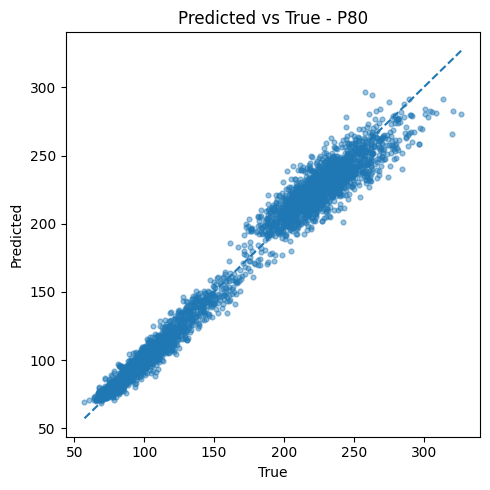

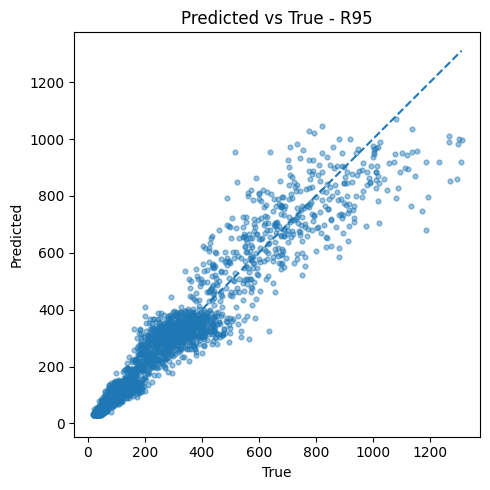

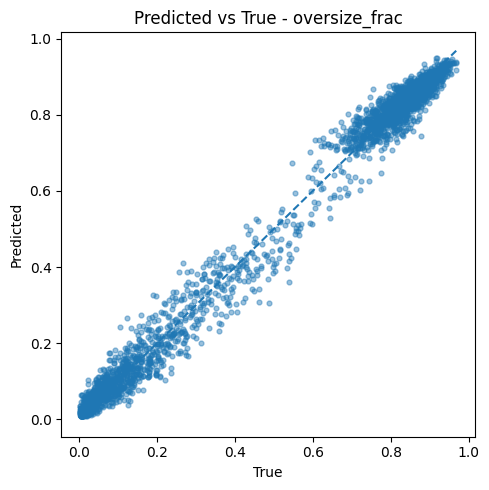

In [7]:
plot_targets = ["P80", "R95", "oversize_frac"]

for target in plot_targets:
    plt.figure(figsize=(5, 5))
    plt.scatter(y[target], oof_predictions[target], alpha=0.45, s=12)

    min_val = min(y[target].min(), oof_predictions[target].min())
    max_val = max(y[target].max(), oof_predictions[target].max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.title(f"Predicted vs True - {target}")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

## 8. Gravity-regime error analysis

Gravity is the main driver for distance-related targets.  
This diagnostic checks whether the model behaves consistently across gravity levels.

,gravity,n,MAE,Median_AE,true_mean,pred_mean,relative_MAE,target
0,1.62,990,79.538458,62.560933,504.102546,501.916227,0.157782,R95
1,3.71,1000,30.098760,23.005266,186.685165,187.774066,0.161227,R95
2,9.81,940,10.182313,7.363774,59.900523,60.276036,0.169987,R95
3,1.62,990,99.072669,84.770424,617.765891,615.251935,0.160373,R50_fines
4,3.71,1000,37.477646,30.402854,231.088286,232.135520,0.162179,R50_fines
5,9.81,940,12.442857,10.149459,72.569602,73.003809,0.171461,R50_fines
6,1.62,990,44.581109,33.971505,251.674665,250.968546,0.177138,R50_oversize
7,3.71,1000,16.715546,12.823293,92.754582,93.221150,0.180213,R50_oversize
8,9.81,940,5.649834,4.170506,29.572605,29.767478,0.191050,R50_oversize


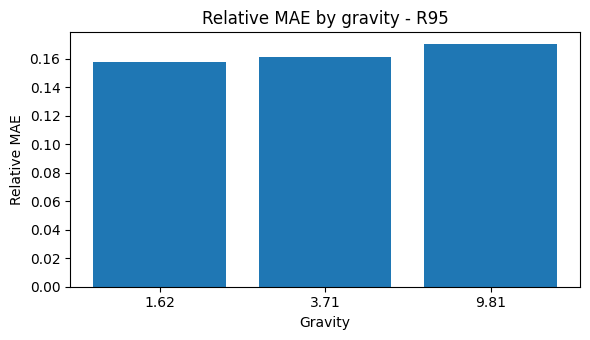

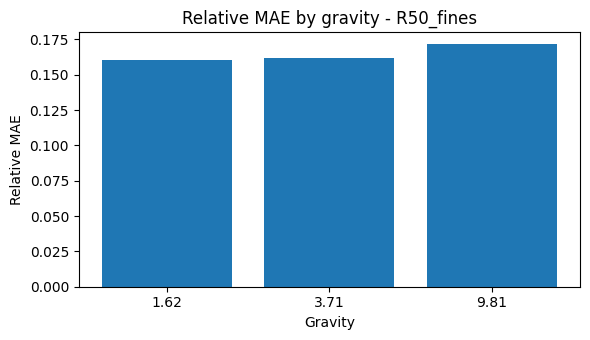

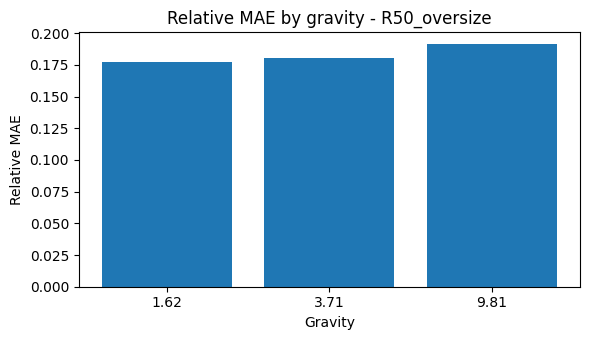

In [8]:
gravity_error_rows = []

for target in distance_targets:
    abs_error = (oof_predictions[target] - y[target]).abs()

    temp = pd.DataFrame({
        "gravity": raw_train["gravity"],
        "target": target,
        "abs_error": abs_error,
        "true_value": y[target],
        "prediction": oof_predictions[target],
    })

    grouped = (
        temp
        .groupby("gravity")
        .agg(
            n=("abs_error", "size"),
            MAE=("abs_error", "mean"),
            Median_AE=("abs_error", "median"),
            true_mean=("true_value", "mean"),
            pred_mean=("prediction", "mean"),
        )
        .reset_index()
    )

    grouped["relative_MAE"] = grouped["MAE"] / (grouped["true_mean"].abs() + 1e-9)
    grouped["target"] = target

    gravity_error_rows.append(grouped)

gravity_error_df = pd.concat(gravity_error_rows, ignore_index=True)
display(gravity_error_df)

gravity_error_df.to_csv(REPORTS_DIR / "diagnostics_error_by_gravity.csv", index=False)

for target in distance_targets:
    temp = gravity_error_df[gravity_error_df["target"] == target]

    plt.figure(figsize=(6, 3.5))
    plt.bar(temp["gravity"].astype(str), temp["relative_MAE"])
    plt.title(f"Relative MAE by gravity - {target}")
    plt.xlabel("Gravity")
    plt.ylabel("Relative MAE")
    plt.tight_layout()
    plt.show()

### Gravity-regime insight

Absolute errors are larger in low-gravity regimes because true travel distances are larger.  
Relative errors are more stable across gravity levels, which suggests that the model captures the main gravity-distance pattern.  
However, distance targets still require careful OOD and plausibility checks because long-range cases are the most difficult.

## 9. Learning curves

Learning curves help check whether adding more data could improve performance.  
To keep the notebook light, we plot learning curves for three representative targets.

,train_size,train_MAE_mean,train_MAE_std,valid_MAE_mean,valid_MAE_std,target
0,468,3.685716,0.070506,8.197465,0.288328,P80
1,937,3.519270,0.050733,8.023082,0.344327,P80
2,1406,3.415404,0.023846,7.927079,0.303966,P80
3,1875,3.374815,0.020285,7.874736,0.333117,P80
4,2344,3.305331,0.034055,7.763811,0.316173,P80


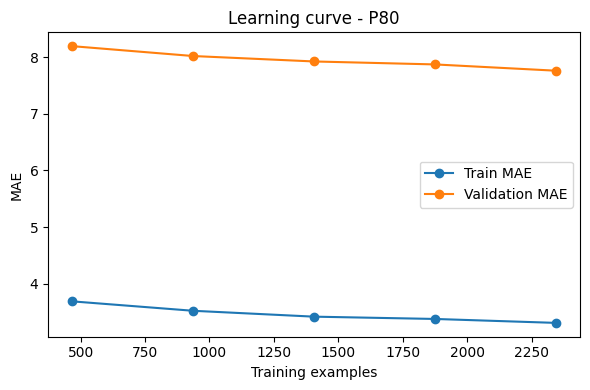

,train_size,train_MAE_mean,train_MAE_std,valid_MAE_mean,valid_MAE_std,target
0,468,17.640228,0.006684,42.021099,2.057745,R95
1,937,16.129824,0.373478,41.112051,2.435246,R95
2,1406,15.885545,0.349989,40.465587,1.893750,R95
3,1875,15.751907,0.094793,40.188152,2.003484,R95
4,2344,15.850356,0.209308,40.097848,1.770841,R95


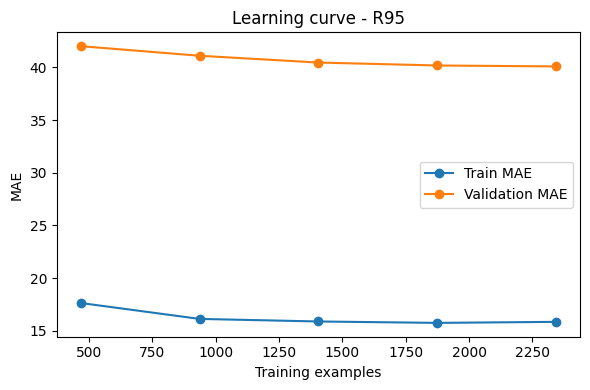

,train_size,train_MAE_mean,train_MAE_std,valid_MAE_mean,valid_MAE_std,target
0,468,0.012389,0.000143,0.028677,0.001174,oversize_frac
1,937,0.011964,0.000141,0.027707,0.001200,oversize_frac
2,1406,0.011746,0.000093,0.027213,0.000818,oversize_frac
3,1875,0.011643,0.000108,0.027017,0.000983,oversize_frac
4,2344,0.011341,0.000123,0.026466,0.000963,oversize_frac


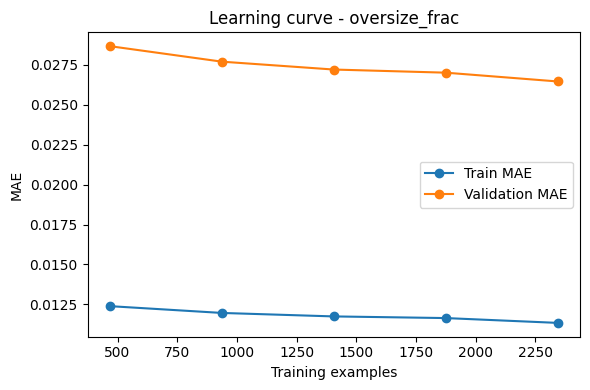

In [9]:
learning_targets = ["P80", "R95", "oversize_frac"]

for target in learning_targets:
    features = get_features_for_target(target)
    pipe = build_extratrees_pipeline(features, random_state=42)

    train_sizes, train_scores, valid_scores = learning_curve(
        pipe,
        X_fe_train,
        y[target],
        cv=5,
        train_sizes=np.linspace(0.2, 1.0, 5),
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    train_mae = -train_scores
    valid_mae = -valid_scores

    curve_df = pd.DataFrame({
        "train_size": train_sizes,
        "train_MAE_mean": train_mae.mean(axis=1),
        "train_MAE_std": train_mae.std(axis=1),
        "valid_MAE_mean": valid_mae.mean(axis=1),
        "valid_MAE_std": valid_mae.std(axis=1),
        "target": target,
    })

    display(curve_df)

    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, curve_df["train_MAE_mean"], marker="o", label="Train MAE")
    plt.plot(train_sizes, curve_df["valid_MAE_mean"], marker="o", label="Validation MAE")
    plt.title(f"Learning curve - {target}")
    plt.xlabel("Training examples")
    plt.ylabel("MAE")
    plt.legend()
    plt.tight_layout()
    plt.show()

    curve_df.to_csv(REPORTS_DIR / f"learning_curve_{target}.csv", index=False)

## 10. Diagnostics summary

The diagnostics support the following conclusions:

- The ExtraTrees baseline is strong for fragmentation targets.
- Distance targets remain harder, especially because low-gravity cases have larger true ranges.
- The model captures the main gravity-distance pattern, but extreme distance cases require additional OOD checks.
- Learning curves help confirm whether the model is limited mainly by data size or by model bias.
- The next step is to test a targeted MLP or controlled blend only for distance targets, instead of replacing the full model.